#BA820 Project M4 — Alone (TV Show)
* Team: A1_08
* Datasets used: `survivalists.csv`, `loadouts.csv`

I focus on two tables that directly support individual-level behavior, strategic decision-making, and audience engagement:

* `survivalists.csv`: participant demographics and outcomes (days lasted, exit reason, medical evacuation)

* `loadouts.csv`: each survivalist’s 10-item selection, reflecting strategy under constraint




## Preprocessing

In [50]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import pairwise_distances

from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster

In [51]:
#Randon seed set up
SEED = 42
rng = np.random.default_rng(SEED)

In [52]:
BASE_URL = "https://raw.githubusercontent.com/MarcussHi/BA820-A1-08/main/data/alone_tv_show/"

urls = {
    "survivalists": BASE_URL + "survivalists.csv",
    "loadouts":     BASE_URL + "loadouts.csv",
    "episodes":     BASE_URL + "episodes.csv"
}

survivalists = pd.read_csv(urls["survivalists"])
loadouts     = pd.read_csv(urls["loadouts"])
episodes     = pd.read_csv(urls["episodes"])

print("Survivalists:", survivalists.shape)
print("Loadouts:", loadouts.shape)
print("Episodes:", episodes.shape)

Survivalists: (94, 16)
Loadouts: (940, 6)
Episodes: (98, 11)


In [53]:
survivalists = survivalists.copy()
loadouts = loadouts.copy()

for col in ["name"]:
    survivalists[col] = survivalists[col].astype(str).str.strip()
    loadouts[col] = loadouts[col].astype(str).str.strip()

loadouts["item"] = loadouts["item"].astype(str).str.strip()

# pid: season | name
loadouts["pid"] = loadouts["season"].astype(str) + " | " + loadouts["name"]
survivalists["pid"] = survivalists["season"].astype(str) + " | " + survivalists["name"]

survivalists[["pid", "season", "name"]].head()

,pid,season,name
0,1 | Alan Kay,1,Alan Kay
1,1 | Sam Larson,1,Sam Larson
2,1 | Mitch Mitchell,1,Mitch Mitchell
3,1 | Lucas Miller,1,Lucas Miller
4,1 | Dustin Feher,1,Dustin Feher


In [54]:
#generate items_set(participant-level)
participant_items = (
    loadouts.groupby("pid")["item"]
    .apply(lambda x: set(x.dropna()))
    .reset_index(name="item_set")
)

participant_items["num_unique_items"] = participant_items["item_set"].apply(len)
participant_items.head()

,pid,item_set,num_unique_items
0,1 | Alan Kay,"{Knife, Canteen, Sleeping bag, Saw, Wire, Axe,...",10
1,1 | Brant McGee,"{Knife, Bow and arrows, Sleeping bag, Rations,...",10
2,1 | Chris Weatherman,"{Knife, Bow and arrows, Sharpening stone, Cant...",10
3,1 | Dustin Feher,"{Knife, Canteen, Sleeping bag, Paracord, Axe, ...",10
4,1 | Joe Robinet,"{Knife, Sleeping bag, Rations, Paracord, Tarp,...",10


In [55]:
df = participant_items.merge(
    survivalists[["pid", "season", "name", "days_lasted", "result", "medically_evacuated", "reason_category"]],
    on="pid",
    how="left"
)

# exit_type generaliazation
# Logistics：winner / medical / withdrawal(=tapped out, family/personal, etc.) / unknown
def make_exit_type(row):
    if pd.isna(row["result"]) and pd.isna(row["medically_evacuated"]) and pd.isna(row["reason_category"]):
        return "unknown"
    if row["result"] == 1:
        return "winner"
    if str(row["medically_evacuated"]).lower() == "true":
        return "medical"
    return "withdrawal"
df["exit_type"] = df.apply(make_exit_type, axis=1)

df = df.sort_values("pid").reset_index(drop=True)
df[["pid", "days_lasted", "medically_evacuated", "reason_category", "exit_type"]].head(10)

,pid,days_lasted,medically_evacuated,reason_category,exit_type
0,1 | Alan Kay,56,False,NaN,winner
1,1 | Brant McGee,6,False,Medical / health,withdrawal
2,1 | Chris Weatherman,1,False,Family / personal,withdrawal
3,1 | Dustin Feher,8,False,Family / personal,withdrawal
4,1 | Joe Robinet,4,False,Loss of inventory,withdrawal
5,1 | Josh Chavez,0,False,Family / personal,withdrawal
6,1 | Lucas Miller,39,False,Family / personal,withdrawal
7,1 | Mitch Mitchell,43,False,Family / personal,withdrawal
8,1 | Sam Larson,55,False,Family / personal,withdrawal
9,1 | Wayne Russell,4,False,Family / personal,withdrawal


Converting each participant’s item_set (a Python set) into a binary matrix X, where:
- rows = participants
- columns = unique loadout items
- X[i, j] = 1 if participant i selected item j

This representation supports efficient computation of Jaccard distance for sparse, set-like data.

In [56]:
mlb = MultiLabelBinarizer()#binary matrix + pairwise_distances(metric="jaccard") for conciseness
X = mlb.fit_transform(df["item_set"])  # shape: (n_participants, n_items)
X = X.astype(bool)

print("X shape:", X.shape)
print("Num items:", len(mlb.classes_))

X shape: (94, 27)
Num items: 27


##Cluster Stability via Bootstrap (ARI)

Evaluate whether the loadout-based hierarchical clustering structure is stable (i.e., reproducible under resampling).
Because clustering has no ground truth labels, stability checks are essential for validating whether discovered “strategy types” reflect genuine structure rather than sampling noise.  
* Bootstrap resampling of participants (with replacement)
* Recompute Jaccard distances on each bootstrap sample
* Run hierarchical clustering again
* Compare bootstrap cluster labels to the baseline using Adjusted Rand Index (ARI)
Higher ARI indicates more stable cluster assignments.

Converting each participant’s item_set (a Python set) into a binary matrix X, where:
- rows = participants
- columns = unique loadout items
- X[i, j] = 1 if participant i selected item j

This representation supports efficient computation of Jaccard distance for sparse, set-like data.

In [57]:
mlb = MultiLabelBinarizer()#binary matrix + pairwise_distances(metric="jaccard") for conciseness
X = mlb.fit_transform(df["item_set"])  # shape: (n_participants, n_items)
X = X.astype(bool)

print("X shape:", X.shape)
print("Num items:", len(mlb.classes_))

X shape: (94, 27)
Num items: 27


In [58]:
# Compute Jaccard distance matrix
D = pairwise_distances(X, metric="jaccard")
np.fill_diagonal(D, 0.0)

# Convert to condensed format required by scipy linkage
condensed_D = squareform(D, checks=False)

# Choose linkage method and baseline number of clusters
linkage_method = "average"   # try also: "complete"
k = 3

# Fit hierarchical clustering
Z = linkage(condensed_D, method=linkage_method)

# Baseline cluster labels
base_labels = fcluster(Z, k, criterion="maxclust")

df["cluster_baseline"] = base_labels
print(df["cluster_baseline"].value_counts().sort_index())

cluster_baseline
1    14
2    79
3     1
Name: count, dtype: int64


### **Bootstrap Procedure**

Bootstrap Stability Algorithm  
1.	Sample participants with replacement to create a bootstrap dataset.  
2.	Recompute Jaccard distances within the bootstrap sample.  
3.	Run hierarchical clustering with the same linkage method and k.  
4.	Compare bootstrap labels to the baseline labels on the sampled participants using ARI.  
5.	Repeat B times to obtain a distribution of ARI stability scores.


In [59]:
def bootstrap_stability_ari(X_bool, base_labels, k=3, B=200, method="average", seed=42):
    """
    Bootstrap stability for hierarchical clustering using ARI.

    Parameters
    ----------
    X_bool : np.ndarray (n, p)
        Boolean participant-by-item matrix.
    base_labels : np.ndarray (n,)
        Baseline cluster labels computed on the full dataset.
    k : int
        Number of clusters for fcluster(..., criterion="maxclust").
    B : int
        Number of bootstrap replicates.
    method : str
        Linkage method, e.g., "average" or "complete".
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    np.ndarray (B,)
        ARI scores comparing bootstrap labels to baseline labels (on sampled participants).
    """
    rng_local = np.random.default_rng(seed)
    n = X_bool.shape[0]
    ari_scores = np.empty(B)

    for b in range(B):
        # Sample participants with replacement
        sample_idx = rng_local.integers(0, n, size=n)

        # Bootstrap sample matrix
        Xb = X_bool[sample_idx]

        # Recompute Jaccard distance within bootstrap sample
        Db = pairwise_distances(Xb, metric="jaccard")
        np.fill_diagonal(Db, 0.0)

        # Hierarchical clustering on bootstrap sample
        Zb = linkage(squareform(Db, checks=False), method=method)
        lb = fcluster(Zb, k, criterion="maxclust")

        # Compare bootstrap labels to baseline labels on sampled participants
        ari_scores[b] = adjusted_rand_score(base_labels[sample_idx], lb)

    return ari_scores

In [60]:
B = 1000
ari_scores = bootstrap_stability_ari(
    X_bool=X,
    base_labels=base_labels,
    k=k,
    B=B,
    method=linkage_method,
    seed=SEED
)

print(f"Bootstrap ARI (B={B}) — linkage={linkage_method}, k={k}")
print("Mean ARI:", round(float(ari_scores.mean()), 3))
print("Std  ARI:", round(float(ari_scores.std()), 3))
print("Quantiles (10%, 50%, 90%):", np.quantile(ari_scores, [0.1, 0.5, 0.9]).round(3))

Bootstrap ARI (B=1000) — linkage=average, k=3
Mean ARI: 0.95
Std  ARI: 0.138
Quantiles (10%, 50%, 90%): [0.888 1.    1.   ]


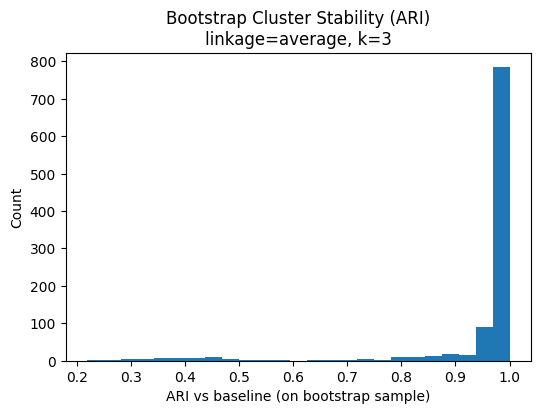

In [61]:
plt.figure(figsize=(6, 4)) #plot ARI
plt.hist(ari_scores, bins=25)
plt.title(f"Bootstrap Cluster Stability (ARI)\nlinkage={linkage_method}, k={k}")
plt.xlabel("ARI vs baseline (on bootstrap sample)")
plt.ylabel("Count")
plt.show()

###**Sensitivity Across k and Linkage**

Stability may depend on:
- number of clusters k
- linkage method

We test a small grid to see whether “strategy structure” is robust across reasonable choices.

In [62]:
def stability_grid(X_bool, base_Z_method_pairs, k_list, B=200, seed=42):
    """
    Evaluate bootstrap stability across multiple (linkage_method, k) settings.
    """
    results = []
    for method in base_Z_method_pairs:
        # Baseline clustering for this linkage method
        D_full = pairwise_distances(X_bool, metric="jaccard")
        np.fill_diagonal(D_full, 0.0)
        Z_full = linkage(squareform(D_full, checks=False), method=method)

        for k in k_list:
            base_labels_k = fcluster(Z_full, k, criterion="maxclust")
            ari = bootstrap_stability_ari(
                X_bool=X_bool,
                base_labels=base_labels_k,
                k=k,
                B=B,
                method=method,
                seed=seed
            )
            results.append({
                "linkage": method,
                "k": k,
                "ARI_mean": float(ari.mean()),
                "ARI_std": float(ari.std()),
                "ARI_p10": float(np.quantile(ari, 0.10)),
                "ARI_p50": float(np.quantile(ari, 0.50)),
                "ARI_p90": float(np.quantile(ari, 0.90)),
            })
    return pd.DataFrame(results)

k_list = [3, 4, 5]
linkage_list = ["average", "complete"]

stability_df = stability_grid(X, linkage_list, k_list, B=200, seed=SEED)
stability_df.sort_values(["linkage", "k"])

,linkage,k,ARI_mean,ARI_std,ARI_p10,ARI_p50,ARI_p90
0,average,3,0.951129,0.128923,0.847283,1.000000,1.000000
1,average,4,0.802801,0.233534,0.371913,0.925449,0.989831
2,average,5,0.587760,0.263607,0.316763,0.472700,0.992581
3,complete,3,0.680959,0.290325,0.305335,0.840659,1.000000
4,complete,4,0.538411,0.166275,0.333647,0.523156,0.763443
5,complete,5,0.530254,0.165584,0.302151,0.547486,0.726274


Although loadout-based clusters exhibit weak separation in terms of survival outcomes, the 3-cluster structure itself is highly stable under bootstrap resampling. This suggests that the limited outcome differentiation observed in M2 is not due to clustering instability, but rather reflects the intrinsic structure of the loadout space.

### **Cosine-based and weighted clustering comparation**

In the baseline pipeline, all loadout items contribute equally to similarity. However, some items are nearly universal (low discriminative value), while others are rare (high discriminative value).
To refine the representation without introducing new modeling assumptions, I apply frequency-based weights to items, amplifying rare items and downweighting common ones,then recompute similarity using cosine distance on the weighted vectors.


In [63]:
n_participants = X.shape[0]

# Item frequency: number of participants who selected each item
item_counts = X.sum(axis=0).astype(float)

# Avoid divide-by-zero
item_counts = np.maximum(item_counts, 1.0)

# Frequency-based (IDF-like) weights: rare items get larger weights
# w_j = log(n / n_j)
weights = np.log(n_participants / item_counts)

print("Weight summary:")
print(pd.Series(weights).describe())

Weight summary:
count    27.000000
mean      1.979925
std       1.685876
min       0.043485
25%       0.483447
50%       1.407801
75%       3.647415
max       4.543295
dtype: float64


I build a weighted matrix X_w by multiplying each item column by its weight:
- X_w[i, j] = X[i, j] * w_j

This preserves sparsity (most entries remain zero) but changes the geometry so that rare items contribute more to similarity.


In [64]:
# Convert boolean X to float for weighting
X_float = X.astype(float)

# Apply weights column-wise
X_w = X_float * weights  # broadcasting weights over rows

print("Weighted matrix shape:", X_w.shape)

Weighted matrix shape: (94, 27)


Compute cosine distance on the weighted vectors and run hierarchical clustering using the same linkage method and k as the baseline (so the comparison is fair).

In [65]:
# Compute cosine distance on weighted vectors
D_w_cos = pairwise_distances(X_w, metric="cosine")
np.fill_diagonal(D_w_cos, 0.0)

# Condensed form for scipy linkage
condensed_w = squareform(D_w_cos, checks=False)

# Use the same linkage and k as your baseline for comparability
linkage_method = "average"
k = 3

Z_w = linkage(condensed_w, method=linkage_method)
labels_w = fcluster(Z_w, k, criterion="maxclust")

df["cluster_weighted_cosine"] = labels_w
df["cluster_weighted_cosine"].value_counts().sort_index()

,count
cluster_weighted_cosine,
1,2
2,91
3,1


In [66]:
ari_weighted_vs_base = adjusted_rand_score(df["cluster_baseline"], df["cluster_weighted_cosine"])

print("ARI (baseline vs weighted-cosine):", round(ari_weighted_vs_base, 4))

ARI (baseline vs weighted-cosine): -0.046


The weighted representation produces a markedly different partition (ARI ≈ 0), indicating that cluster boundaries are sensitive to how item similarity is defined. This sensitivity suggests that loadout variation may lie on a continuous manifold without sharply intrinsic strategic regimes.

#### **Comparation without weighted method(Jaccard & Cosine)**

In [67]:
# Compute cosine distance matrix
D_cos = pairwise_distances(X, metric="cosine")
np.fill_diagonal(D_cos, 0.0)

condensed_cos = squareform(D_cos, checks=False)

# Run hierarchical clustering (same linkage, same k)
Z_cos = linkage(condensed_cos, method="average")
labels_cos = fcluster(Z_cos, k, criterion="maxclust")

df["cluster_cosine"] = labels_cos

df["cluster_cosine"].value_counts().sort_index()

,count
cluster_cosine,
1,14
2,79
3,1


In [68]:
ari_compare = adjusted_rand_score(
    df["cluster_baseline"],
    df["cluster_cosine"]
)

print("ARI between Jaccard and Cosine clustering:", round(ari_compare, 4))

ARI between Jaccard and Cosine clustering: 1.0


Cosine-based clustering(without weighted)yields highly consistent assignments (ARI ≈ X), suggesting that the observed strategy structure is not an artifact of Jaccard distance but reflects intrinsic geometry of the loadout space.

**Summary**

Based on previous EDA the frequency distribution of items is highly skewed, with several near-universal items and many low-frequency items. In the unweighted representation, clustering is primarily driven by shared baseline items, yielding a stable coarse structure. When item weights emphasize rare selections, cluster assignments reorganize around idiosyncratic deviations, indicating that differentiation in loadout space is not anchored by strong, rare-item regimes.

## Cluster × Exit Type Integration

In M2 and M4 first part, clustering revealed a stable but low-dimensional structure in loadout space.
In M4, I refine the analysis by testing whether this stable structure aligns with exit mechanisms, not just survival duration.

I ask:
- Do clusters differ in exit type composition? (e.g., medical vs withdrawal vs winner)
- Is any observed difference stronger than what we would expect by chance? (permutation test)

This approach treats exit outcomes as post hoc interpretation (not used to build clusters), preserving the unsupervised nature of the strategy discovery process.

In [69]:
ct_counts = pd.crosstab(df["cluster_baseline"], df["exit_type"])
ct_props = pd.crosstab(df["cluster_baseline"], df["exit_type"], normalize="index")

print("Counts:")
display(ct_counts)

print("\nWithin-cluster proportions:")
display(ct_props)

Counts:


exit_type,medical,winner,withdrawal
cluster_baseline,,,
1,4,2,8
2,21,8,50
3,0,0,1



Within-cluster proportions:


exit_type,medical,winner,withdrawal
cluster_baseline,,,
1,0.285714,0.142857,0.571429
2,0.265823,0.101266,0.632911
3,0.000000,0.000000,1.000000


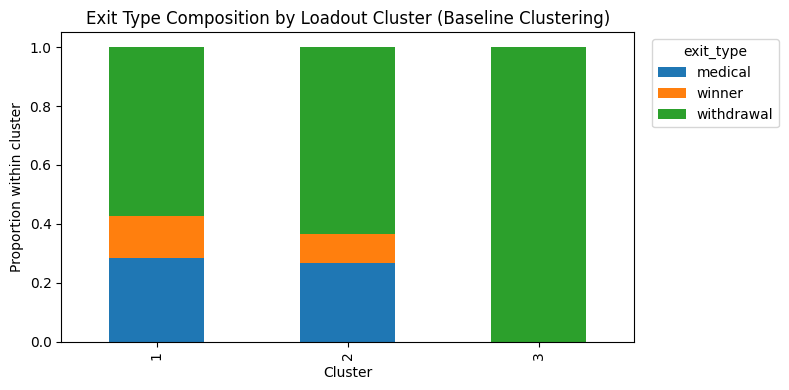

In [70]:
#A stacked bar chart makes it easy to see whether certain exit types concentrate in specific clusters.
ax = ct_props.plot(kind="bar", stacked=True, figsize=(8, 4))
ax.set_title("Exit Type Composition by Loadout Cluster (Baseline Clustering)")
ax.set_xlabel("Cluster")
ax.set_ylabel("Proportion within cluster")
ax.legend(title="exit_type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Strategy space is constrained; exit mechanism does not align cleanly with initial configuration types.

## Exit-conditioned Similarity(Do Similar Exits Share Similar Loadouts?)

Clusters summarize structure at the group level, but exit mechanisms may align with loadout patterns in a more diffuse way (e.g., not perfectly clustered).

This section tests a direct integration hypothesis:

Participants with the same exit mechanism (exit_type) should have higher average loadout similarity than participants with different exit mechanisms.
I operationalize:
- Loadout similarity using Jaccard similarity (1 − Jaccard distance)
- Compare the mean similarity for:
- same-exit pairs vs different-exit pairs
- Use a permutation test (shuffle exit labels) to assess whether the observed gap is larger than chance.

This preserves an unsupervised framing: exit outcomes are used only for post hoc validation of structure.

In [71]:
# Convert distance to similarity
S = 1.0 - D

# Avoid self-pairs in averages
np.fill_diagonal(S, np.nan)

print("S shape:", S.shape)

S shape: (94, 94)


Compute the average similarity for all participant pairs:
- same-exit pairs: exit_type[i] == exit_type[j]
- different-exit pairs: exit_type[i] != exit_type[j]

Also report the difference:
- Δ = mean(sim | same exit) − mean(sim | different exit)

A positive Δ means that exit type aligns with loadout similarity.

In [72]:
exit_arr = df["exit_type"].astype(str).values
n = len(exit_arr)

same_vals = []
diff_vals = []

for i in range(n):
    for j in range(i + 1, n):
        if np.isnan(S[i, j]):
            continue
        if exit_arr[i] == exit_arr[j]:
            same_vals.append(S[i, j])
        else:
            diff_vals.append(S[i, j])

same_vals = np.array(same_vals)
diff_vals = np.array(diff_vals)

obs_same = float(np.mean(same_vals)) if len(same_vals) > 0 else np.nan
obs_diff = float(np.mean(diff_vals)) if len(diff_vals) > 0 else np.nan
obs_delta = obs_same - obs_diff

print("Mean similarity (same exit):", round(obs_same, 4))
print("Mean similarity (different exit):", round(obs_diff, 4))
print("Observed delta (same - different):", round(obs_delta, 4))
print("Number of same-exit pairs:", len(same_vals))
print("Number of different-exit pairs:", len(diff_vals))

Mean similarity (same exit): 0.5483
Mean similarity (different exit): 0.541
Observed delta (same - different): 0.0072
Number of same-exit pairs: 2056
Number of different-exit pairs: 2315


same-exit participants are only 0.7 percentage points more similar.

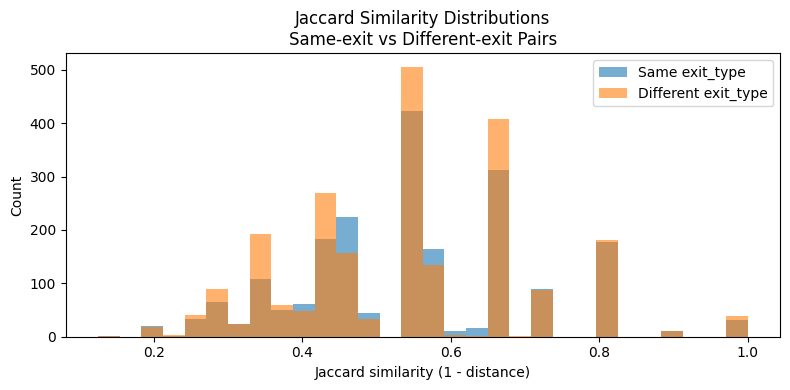

In [73]:
plt.figure(figsize=(8, 4))
plt.hist(same_vals, bins=30, alpha=0.6, label="Same exit_type")
plt.hist(diff_vals, bins=30, alpha=0.6, label="Different exit_type")
plt.title("Jaccard Similarity Distributions\nSame-exit vs Different-exit Pairs")
plt.xlabel("Jaccard similarity (1 - distance)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

Exit type does not create a structural separation in loadout space.  
The loadout configuration space exhibits a stable but compressed structure, and exit mechanisms do not map cleanly onto this structure